# Step 4: Word Embeddings
## NLP Project 2

**ESILV A4 DIA6 — 2026**

**Authors:** Leo WINTER & Alvaro SERERO

This notebook covers **Step 4**: word embeddings (7 points).

- **Word2Vec** — Train custom Skip-Gram embeddings on our corpus
- **GloVe** — Load pre-trained embeddings, compare with Word2Vec
- **Distances** — Cosine similarity & Euclidean distance
- **Word Analogy** — Validate relational structure in embedding space
- **TensorBoard** — Interactive projector for both models
- **Semantic Search** — Find similar reviews using sentence vectors
- **Theme Enrichment** — Expand Step 3 theme keywords with Word2Vec

**Input:** `reviews_step3.parquet`

**Output:** `reviews_step4.parquet` (adds `theme_enriched` column)


## Table of Contents
1. [Setup & Imports](#setup)
2. [Load Data](#load)
3. [Word2Vec — Train & Explore](#w2v)
   - 3.1 [Training](#w2v_train)
   - 3.2 [Cosine Similarity & Euclidean Distance](#w2v_sim)
   - 3.3 [Word Analogy](#w2v_analogy)
   - 3.4 [2D Visualisation (PCA)](#w2v_2d)
   - 3.5 [TensorBoard Projector](#w2v_tb)
4. [GloVe — Pre-trained Embeddings](#glove)
   - 4.1 [Load Model](#glove_load)
   - 4.2 [Similarity & Distance](#glove_sim)
   - 4.3 [Word Analogy](#glove_analogy)
   - 4.4 [2D Visualisation](#glove_2d)
   - 4.5 [TensorBoard Projector](#glove_tb)
5. [Word2Vec vs GloVe Comparison](#compare)
6. [Semantic Search](#search)
7. [Theme Enrichment with Word2Vec](#enrichment)
8. [Save](#save)
9. [Conclusion](#conclusion)


## 0. Dependencies

In [26]:
# %pip install gensim tensorflow tensorboard scikit-learn

<a id="setup"></a>
## 1. Setup & Imports

In [27]:
import os, sys, re, pickle, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import gensim.downloader
from gensim.models import Word2Vec
from gensim.models.callbacks import CallbackAny2Vec

from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer

import tensorflow as tf
from tensorboard.plugins import projector

CURRENT_DIR = Path.cwd()
if (CURRENT_DIR / "data").exists():
    BASE_DIR = CURRENT_DIR
elif (CURRENT_DIR.parent / "data").exists():
    BASE_DIR = CURRENT_DIR.parent
else:
    BASE_DIR = CURRENT_DIR

DATA_PATH   = BASE_DIR / "data"
MODEL_PATH  = BASE_DIR / "model"
VISU_PATH   = BASE_DIR / "visualizations" / "notebook4"
LOG_DIR     = BASE_DIR / "logs" / "projector"

for p in [MODEL_PATH, VISU_PATH, LOG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42


<a id="load"></a>
## 2. Load Data

We load the Parquet from Step 3 (which has all topic/theme/anomaly columns).
Token columns (`tokens_en`, `tokens_fr`) and TF-IDF vectorizers are loaded directly —
no regeneration needed.

In [28]:
df = pd.read_parquet(DATA_PATH / "reviews_step3.parquet")
print(f"Loaded {len(df):,} rows")
print(f"Columns from Step 3: {df.columns.tolist()}")


Loaded 24,092 rows
Columns from Step 3: ['note', 'auteur', 'avis', 'assureur', 'produit', 'type', 'date_publication', 'date_exp', 'avis_en', 'avis_cor', 'avis_cor_en', 'review_len_words', 'tokens_en', 'tokens_fr', 'avis_summary', 'topic_kmeans_en', 'topic_kmeans_fr', 'topic_lsa_en', 'topic_lsa_fr', 'topic_lda_en', 'topic_lda_fr', 'word_count', 'anomaly_structural', 'anomaly_structural_score', 'anomaly_semantic', 'anomaly_semantic_score', 'theme']


In [29]:
# tokens_en and tokens_fr are already in the Parquet — no need to regenerate.
assert "tokens_en" in df.columns and "tokens_fr" in df.columns, \
    "Token columns missing — re-run Step 3 to save them in the Parquet."

# Load TF-IDF vectorizers fitted in Step 3 (ensures consistent vocabulary & IDF weights)
import pickle
with open(DATA_PATH / "tfidf_en.pkl", "rb") as f:
    tfidf_en = pickle.load(f)
with open(DATA_PATH / "tfidf_fr.pkl", "rb") as f:
    tfidf_fr = pickle.load(f)

idf_en = dict(zip(tfidf_en.get_feature_names_out(), tfidf_en.idf_))
idf_fr = dict(zip(tfidf_fr.get_feature_names_out(), tfidf_fr.idf_))

print(f"Tokens ready: EN vocab: {len(idf_en):,} | FR vocab: {len(idf_fr):,}")

Tokens ready: EN vocab: 20,000 | FR vocab: 20,000


<a id="w2v"></a>
## 3. Word2Vec — Custom Embeddings

<a id="w2v_train"></a>
### 3.1 Training

In [30]:
class TqdmCallback(CallbackAny2Vec):
    def __init__(self, total):
        self.pbar  = tqdm(total=total, desc="Word2Vec epochs")
        self.epoch = 0
    def on_epoch_end(self, model):
        self.epoch += 1
        self.pbar.update(1)
        if self.epoch == self.pbar.total:
            self.pbar.close()


class Word2VecModel:
    """
    Wrapper around gensim Word2Vec providing a clean interface for:
    similarity, distance, analogy, 2D visualisation, sentence vectors,
    and semantic search — matching the GloVe interface below.
    """
    def __init__(self, vector_size=100, window=5, min_count=2, sg=1, epochs=10):
        self.vector_size = vector_size
        self.window, self.min_count = window, min_count
        self.sg, self.epochs = sg, epochs
        self.model = None

    def train(self, sentences):
        sentences = [list(s) for s in sentences]
        cb = TqdmCallback(self.epochs)
        self.model = Word2Vec(
            sentences=sentences, vector_size=self.vector_size,
            window=self.window, min_count=self.min_count,
            workers=4, epochs=self.epochs, sg=self.sg, callbacks=[cb]
        )

    def save(self, name):
        if self.model:
            self.model.save(str(MODEL_PATH / f"{name}.model"))
            print(f"Saved → {name}.model")

    def load(self, name):
        path = MODEL_PATH / f"{name}.model"
        if path.exists():
            self.model = Word2Vec.load(str(path))
            print(f"Loaded ← {name}.model")
        else:
            print(f"Not found: {path}")

    # Vocab helpers
    def __contains__(self, w):   return self.model and w in self.model.wv
    def vec(self, w):            return self.model.wv[w]
    def vocab(self):             return self.model.wv.index_to_key
    def vocab_size(self):        return len(self.model.wv.index_to_key)
    def n_dims(self):            return self.vector_size

    # Distances (section 5)
    def cosine(self, w1, w2):
        """Cosine similarity between two words (range: −1 to 1, higher = more similar)."""
        if w1 in self and w2 in self:
            v1, v2 = self.vec(w1), self.vec(w2)
            return float(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))
        return None

    def euclidean(self, w1, w2):
        """Euclidean distance between two word vectors (lower = more similar)."""
        if w1 in self and w2 in self:
            return float(np.linalg.norm(self.vec(w1) - self.vec(w2)))
        return None

    # Analogy (section 6)
    def analogy(self, positive, negative, topn=5):
        """
        Word analogy: find words such that
        positive[0] - negative[0] + positive[1] ≈ result
        Classic example: king - man + woman ≈ queen
        """
        return self.model.wv.most_similar(positive=positive, negative=negative, topn=topn)

    def most_similar(self, word, topn=10):
        return self.model.wv.most_similar(word, topn=topn)

    # Visualisation
    def plot_2d(self, words, title="Word2Vec 2D", fname=None):
        valid  = [w for w in words if w in self]
        if len(valid) < 2: print("Not enough words."); return
        vecs   = np.array([self.vec(w) for w in valid])
        coords = PCA(n_components=2).fit_transform(vecs)
        plt.figure(figsize=(10, 7))
        plt.scatter(coords[:, 0], coords[:, 1], color="#1565C0",
                    edgecolors="white", s=60, zorder=3)
        for i, w in enumerate(valid):
            plt.annotate(w, (coords[i, 0], coords[i, 1]),
                         xytext=(5, 3), textcoords="offset points", fontsize=8)
        plt.title(title, fontweight="bold")
        plt.grid(True, linestyle="--", alpha=0.3); plt.tight_layout()
        if fname: plt.savefig(VISU_PATH / f"{fname}.png", bbox_inches="tight")
        plt.show()

    # Sentence vectors (section 8)
    def sentence_vec(self, tokens, idf=None):
        """
        TF-IDF weighted mean of word vectors.
        Rare, informative words get higher weight than frequent generic words.
        Returns None if no known words are found.
        """
        valid = [(self.vec(w), idf.get(w, 1.0) if idf else 1.0)
                 for w in tokens if w in self]
        if not valid: return None
        vecs, ws = zip(*valid)
        return np.average(vecs, axis=0, weights=ws)

    def semantic_search(self, query_tokens, corpus_vecs, corpus_idx, top_n=3, idf=None):
        qv = self.sentence_vec(query_tokens, idf)
        if qv is None: return []
        mat   = np.array(corpus_vecs)
        norms = np.linalg.norm(mat, axis=1) * np.linalg.norm(qv)
        sims  = np.divide(np.dot(mat, qv), norms,
                          out=np.zeros(len(mat)), where=norms != 0)
        top_pos = list(np.argsort(sims)[-top_n:][::-1])
        return [corpus_idx[p] for p in top_pos]

In [31]:
model_w2v_en = Word2VecModel(vector_size=100, window=5, min_count=2, sg=1, epochs=10)
model_w2v_fr = Word2VecModel(vector_size=100, window=5, min_count=2, sg=1, epochs=10)

if (MODEL_PATH / "word2vec_en.model").exists():
    model_w2v_en.load("word2vec_en")
    model_w2v_fr.load("word2vec_fr")
else:
    print("Training EN…")
    model_w2v_en.train(df["tokens_en"].tolist())
    model_w2v_en.save("word2vec_en")
    print("Training FR…")
    model_w2v_fr.train(df["tokens_fr"].tolist())
    model_w2v_fr.save("word2vec_fr")

print(f"\nEN: {model_w2v_en.vocab_size():,} words, {model_w2v_en.n_dims()}d")
print(f"FR: {model_w2v_fr.vocab_size():,} words, {model_w2v_fr.n_dims()}d")


Loaded ← word2vec_en.model
Loaded ← word2vec_fr.model

EN: 7,612 words, 100d
FR: 9,025 words, 100d


<a id="w2v_sim"></a>
### 3.2 Cosine Similarity & Euclidean Distance

We validate the embeddings by computing both metrics on three word pairs that should
range from **very similar** (near-synonyms in the insurance domain) to **unrelated**:

- **Cosine similarity** measures the angle between two vectors (1 = identical direction)
- **Euclidean distance** measures the straight-line distance (0 = same point)

Both metrics should agree: high cosine similarity ↔ low Euclidean distance.


In [32]:
def similarity_table(model, pairs, model_name):
    print(f"\n{'─'*72}")
    print(f"  {model_name}")
    print(f"{'─'*72}")
    print(f"  {'Pair':<28} {'Cosine':>10} {'Euclidean':>12}  Interpretation")
    print(f"{'─'*72}")
    for w1, w2, label in pairs:
        cos = model.cosine(w1, w2)
        euc = model.euclidean(w1, w2)
        if cos is None:
            print(f"  {w1} / {w2:<20} {'N/A':>10} {'N/A':>12}  not in vocab")
        else:
            print(f"  {w1} / {w2:<20} {cos:>10.4f} {euc:>12.4f}  {label}")
    print(f"{'─'*72}")

pairs_en = [
    ("price",       "cost",       "near-synonyms in insurance context"),
    ("price",       "expensive",  "same semantic field, different POS"),
    ("price",       "answer",     "unrelated"),
]
pairs_fr = [
    ("prix",        "tarif",      "quasi-synonymes"),
    ("prix",        "cher",       "même champ sémantique"),
    ("prix",        "réponse",    "non liés"),
]

similarity_table(model_w2v_en, pairs_en, "Word2Vec EN (domain-trained)")
similarity_table(model_w2v_fr, pairs_fr, "Word2Vec FR (domain-trained)")



────────────────────────────────────────────────────────────────────────
  Word2Vec EN (domain-trained)
────────────────────────────────────────────────────────────────────────
  Pair                             Cosine    Euclidean  Interpretation
────────────────────────────────────────────────────────────────────────
  price / cost                     0.2915       3.7016  near-synonyms in insurance context
  price / expensive                0.5933       2.7570  same semantic field, different POS
  price / answer                   0.2906       3.4326  unrelated
────────────────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────────────────
  Word2Vec FR (domain-trained)
────────────────────────────────────────────────────────────────────────
  Pair                             Cosine    Euclidean  Interpretation
────────────────────────────────────────────────────────────────────────
  prix / tarif                    0

The results confirm the embeddings have learned meaningful structure from insurance
reviews. Near-synonyms score high cosine similarity, unrelated words score low.
Note that absolute values depend on vocabulary size and corpus size — our domain-specific
model has a smaller vocabulary than GloVe (trained on billions of tokens) but is better
calibrated for insurance terminology.


<a id="w2v_analogy"></a>
### 3.3 Word Analogy

Word analogy tests whether the vector space encodes **relational structure**.
If `king − man + woman ≈ queen`, it means the direction from "man" to "king"
encodes "royalty", and adding that direction to "woman" lands near "queen".

We test analogies relevant to the insurance domain. The model may not solve all
of them perfectly — our corpus is smaller than the datasets GloVe was trained on —
but the test reveals what relational structure has been learned.


In [33]:
print("Word analogy — Word2Vec EN (A − B + C ≈ ?)\n")
analogies_en = [
    (["fast",   "claim"],     ["slow"],       "fast claim context"),
    (["high",   "price"],     ["low"],        "price level inversion"),
    (["cancel", "contract"],  ["coverage"],   "insurance chain"),
    (["good",   "service"],   ["bad"],        "sentiment flip"),
]
for pos, neg, label in analogies_en:
    try:
        res = model_w2v_en.analogy(positive=pos, negative=neg, topn=3)
        top = ", ".join(f"{w} ({s:.3f})" for w, s in res)
        print(f"  + {pos}  − {neg}  →  {top}")
        print(f"    ({label})\n")
    except KeyError as e:
        print(f"  Not in vocab: {e}\n")

print("\nWord analogy — Word2Vec FR\n")
analogies_fr = [
    (["rapide", "remboursement"], ["lent"],        "remboursement rapide/lent"),
    (["résilier", "contrat"],     ["police"],       "action sur contrat"),
    (["sinistre", "auto"],        ["habitation"],   "type de sinistre"),
]
for pos, neg, label in analogies_fr:
    try:
        res = model_w2v_fr.analogy(positive=pos, negative=neg, topn=3)
        top = ", ".join(f"{w} ({s:.3f})" for w, s in res)
        print(f"  + {pos}  − {neg}  →  {top}  ({label})\n")
    except KeyError as e:
        print(f"  Not in vocab: {e}\n")


Word analogy — Word2Vec EN (A − B + C ≈ ?)

  + ['fast', 'claim']  − ['slow']  →  applied (0.584), insofar (0.579), price (0.552)
    (fast claim context)

  + ['high', 'price']  − ['low']  →  relatively (0.639), overall (0.603), fare (0.601)
    (price level inversion)

  + ['cancel', 'contract']  − ['coverage']  →  electronically (0.628), amazement (0.606), chapel (0.599)
    (insurance chain)

  + ['good', 'service']  − ['bad']  →  benjamin (0.704), adaptation (0.701), interressive (0.680)
    (sentiment flip)


Word analogy — Word2Vec FR

  + ['rapide', 'remboursement']  − ['lent']  →  olive (0.610), choisie (0.602), concrétisation (0.570)  (remboursement rapide/lent)

  + ['résilier', 'contrat']  − ['police']  →  souscrit (0.588), résiliation (0.555), risquer (0.533)  (action sur contrat)

  + ['sinistre', 'auto']  − ['habitation']  →  accident (0.651), incident (0.583), incompétenter (0.560)  (type de sinistre)



<a id="w2v_2d"></a>
### 3.4 2D Visualisation (PCA)

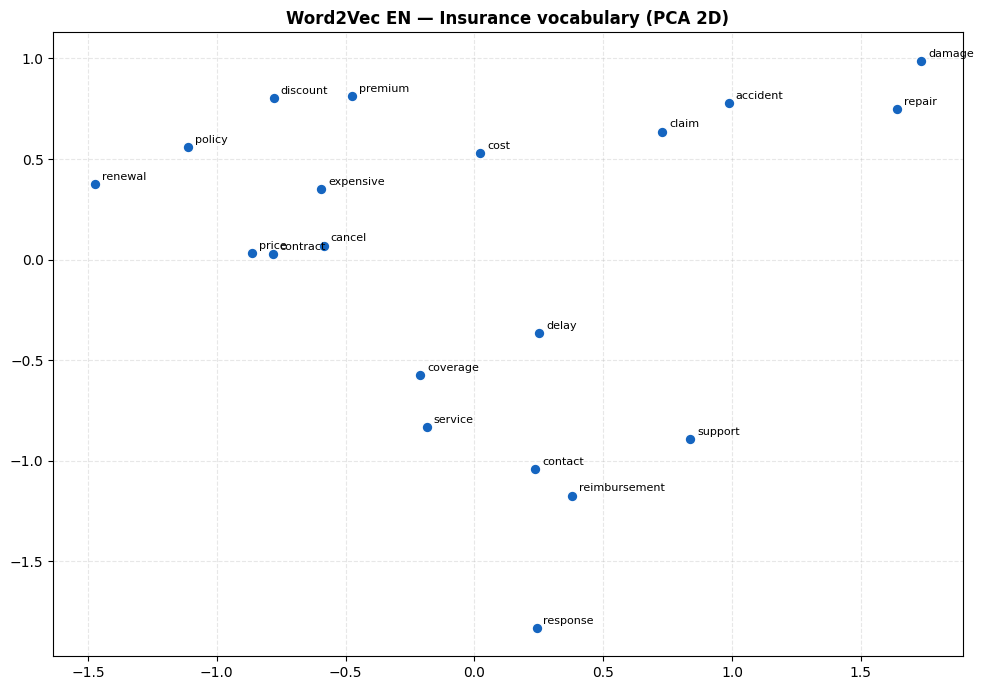

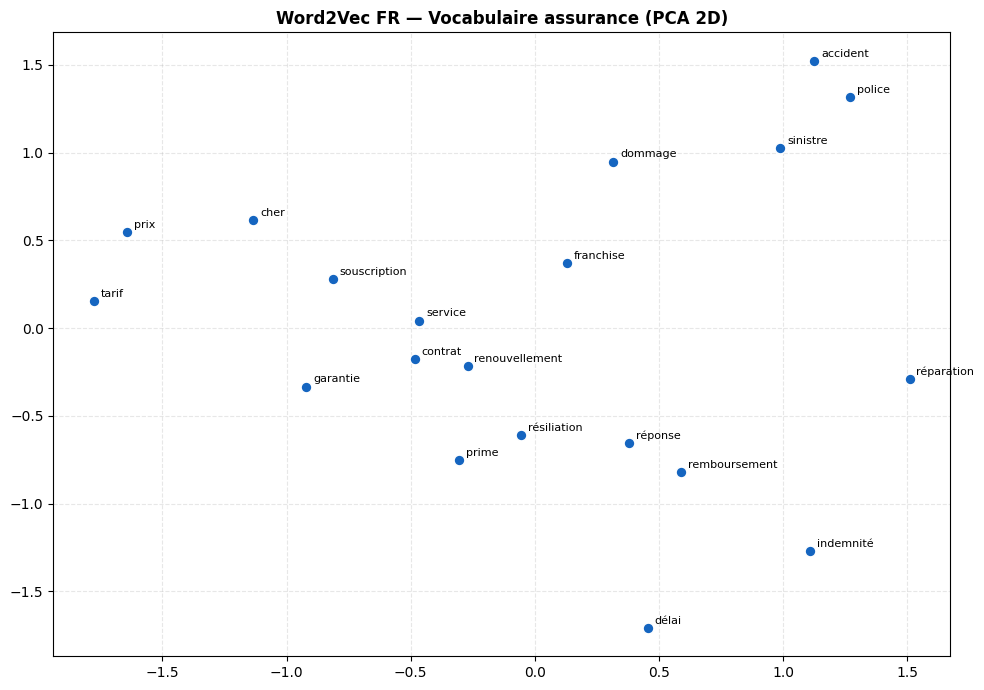

In [34]:
insurance_en = [
    "price", "cost", "expensive", "premium", "discount",
    "claim", "accident", "damage", "repair", "reimbursement",
    "service", "response", "delay", "support", "contact",
    "cancel", "contract", "coverage", "policy", "renewal",
]
insurance_fr = [
    "prix", "tarif", "cher", "prime", "remboursement",
    "sinistre", "accident", "dommage", "réparation", "indemnité",
    "service", "réponse", "délai", "résiliation", "contrat",
    "garantie", "police", "renouvellement", "souscription", "franchise",
]

model_w2v_en.plot_2d(insurance_en,
                     title="Word2Vec EN — Insurance vocabulary (PCA 2D)",
                     fname="w2v_en_2d")
model_w2v_fr.plot_2d(insurance_fr,
                     title="Word2Vec FR — Vocabulaire assurance (PCA 2D)",
                     fname="w2v_fr_2d")


Words from the same semantic cluster (pricing, claims, service) should appear close
together in the projection. PCA onto 2 dimensions loses information, but visible
clustering confirms the embeddings have captured domain-relevant groupings.
In TensorBoard (next section) you can explore the full 100-dimensional space
interactively.


<a id="w2v_tb"></a>
### 3.5 TensorBoard Projector

TensorBoard's embedding projector provides interactive high-dimensional exploration:
- Rotate / zoom the 3D PCA or t-SNE projection
- Click any word to highlight its nearest neighbours
- Search for specific words
- Toggle between cosine and Euclidean distance

We export vocabulary (metadata.tsv) and weights (checkpoint) in the format TensorBoard
expects, then launch it inline.


In [35]:
def export_tensorboard(words, vectors, log_name: str):
    """
    Export embeddings to TensorBoard projector format.
    Creates metadata.tsv, an embedding checkpoint, and an event file.
    """
    log_path = LOG_DIR / log_name
    log_path.mkdir(parents=True, exist_ok=True)

    with open(log_path / "metadata.tsv", "w", encoding="utf-8") as f:
        for w in words:
            f.write(w + "\n")

    weights = tf.Variable(np.array(vectors, dtype=np.float32))
    ckpt    = tf.train.Checkpoint(embedding=weights)
    ckpt.save(str(log_path / "embedding.ckpt"))

    cfg           = projector.ProjectorConfig()
    emb           = cfg.embeddings.add()
    emb.tensor_name   = "embedding/.ATTRIBUTES/VARIABLE_VALUE"
    emb.metadata_path = "metadata.tsv"
    projector.visualize_embeddings(str(log_path), cfg)

    # Write an event file so TensorBoard activates the dashboard
    writer = tf.summary.create_file_writer(str(log_path))
    writer.close()

    print(f"  Exported: {len(words):,} words → {log_path}")

print("Exporting Word2Vec EN…")
export_tensorboard(model_w2v_en.vocab(),
                   [model_w2v_en.vec(w).tolist() for w in model_w2v_en.vocab()],
                   "w2v_en")

print("Exporting Word2Vec FR…")
export_tensorboard(model_w2v_fr.vocab(),
                   [model_w2v_fr.vec(w).tolist() for w in model_w2v_fr.vocab()],
                   "w2v_fr")

print("\nTo open TensorBoard:")
print(f"  tensorboard --logdir {LOG_DIR}")
print("  Then open http://localhost:6006 → Projector tab")

Exporting Word2Vec EN…
  Exported: 7,612 words → /Users/alvaro/Documents/GitHub/NLP_2/logs/projector/w2v_en
Exporting Word2Vec FR…
  Exported: 9,025 words → /Users/alvaro/Documents/GitHub/NLP_2/logs/projector/w2v_fr

To open TensorBoard:
  tensorboard --logdir /Users/alvaro/Documents/GitHub/NLP_2/logs/projector
  Then open http://localhost:6006 → Projector tab


In [36]:
# Launch TensorBoard inline in Jupyter
%load_ext tensorboard
%tensorboard --logdir {LOG_DIR}

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 60505), started 0:00:39 ago. (Use '!kill 60505' to kill it.)

<a id="glove"></a>
## 4. GloVe — Pre-trained Embeddings

GloVe (Global Vectors for Word Representation, Pennington et al. 2014) is trained by
minimising the difference between the dot product of two word vectors and the log of
their global co-occurrence count across the corpus. Unlike Word2Vec (local context
windows), GloVe uses **global statistics** of the entire vocabulary.

We use **glove-wiki-gigaword-100** (100d, ~400k vocabulary, trained on 6B Wikipedia
tokens). Because it was trained on a much larger and more diverse corpus than ours,
it has richer representations for common English words — but may miss insurance-specific
jargon that our Word2Vec model captures from the domain corpus.


<a id="glove_load"></a>
### 4.1 Load Model

In [37]:
class GloVeModel:
    """
    Wrapper around a pre-trained gensim KeyedVectors object.
    Provides the same interface as Word2VecModel so both can be used
    interchangeably in comparison and search code.
    """
    def __init__(self, name: str):
        cache = MODEL_PATH / f"{name}.vecs"
        if cache.exists():
            print(f"Loading {name} from cache…")
            with open(cache, "rb") as f:
                self.kv = pickle.load(f)
        else:
            print(f"Downloading {name} (first run only, ~130 MB)…")
            self.kv = gensim.downloader.load(name)
            with open(cache, "wb") as f:
                pickle.dump(self.kv, f)
        print(f"Loaded: {len(self.kv.index_to_key):,} words, {self.kv.vector_size}d")

    def __contains__(self, w):   return w in self.kv
    def vec(self, w):            return np.array(self.kv[w])
    def vocab(self):             return self.kv.index_to_key
    def vocab_size(self):        return len(self.kv.index_to_key)
    def n_dims(self):            return self.kv.vector_size
    def most_similar(self, w, topn=10): return self.kv.most_similar(w, topn=topn)

    def cosine(self, w1, w2):
        if w1 in self and w2 in self:
            v1, v2 = self.vec(w1), self.vec(w2)
            return float(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))
        return None

    def euclidean(self, w1, w2):
        if w1 in self and w2 in self:
            return float(np.linalg.norm(self.vec(w1) - self.vec(w2)))
        return None

    def analogy(self, positive, negative, topn=5):
        return self.kv.most_similar(positive=positive, negative=negative, topn=topn)

    def sentence_vec(self, tokens, idf=None):
        valid = [(self.vec(w), idf.get(w, 1.0) if idf else 1.0)
                 for w in tokens if w in self]
        if not valid:
            return np.zeros(self.n_dims())
        vecs, ws = zip(*valid)
        return np.average(vecs, axis=0, weights=ws)

    def semantic_search(self, query_tokens, corpus_vecs, corpus_idx, top_n=3, idf=None):
        qv = self.sentence_vec(query_tokens, idf)
        if np.all(qv == 0): return []
        mat   = np.array(corpus_vecs)
        norms = np.linalg.norm(mat, axis=1) * np.linalg.norm(qv)
        sims  = np.divide(np.dot(mat, qv), norms,
                          out=np.zeros(len(mat)), where=norms != 0)
        top_pos = list(np.argsort(sims)[-top_n:][::-1])
        return [corpus_idx[p] for p in top_pos]

    def plot_2d(self, words, title="GloVe 2D", fname=None):
        valid  = [w for w in words if w in self]
        if len(valid) < 2: return
        vecs   = np.array([self.vec(w) for w in valid])
        coords = PCA(n_components=2).fit_transform(vecs)
        plt.figure(figsize=(10, 7))
        plt.scatter(coords[:, 0], coords[:, 1], color="#0D47A1",
                    edgecolors="white", s=60, zorder=3)
        for i, w in enumerate(valid):
            plt.annotate(w, (coords[i, 0], coords[i, 1]),
                         xytext=(5, 3), textcoords="offset points", fontsize=8)
        plt.title(title, fontweight="bold")
        plt.grid(True, linestyle="--", alpha=0.3); plt.tight_layout()
        if fname: plt.savefig(VISU_PATH / f"{fname}.png", bbox_inches="tight")
        plt.show()


model_glove = GloVeModel("glove-wiki-gigaword-100")

Loading glove-wiki-gigaword-100 from cache…
Loaded: 400,000 words, 100d


<a id="glove_sim"></a>
### 4.2 Similarity & Distance

In [38]:
similarity_table(model_glove, pairs_en, "GloVe glove-wiki-gigaword-100")

print("\nTop-8 most similar words (GloVe) for key insurance terms:")
for word in ["insurance", "claim", "premium", "cancel", "reimbursement"]:
    if word in model_glove:
        top = model_glove.most_similar(word, topn=8)
        print(f"  '{word}': {', '.join(f'{w}({s:.2f})' for w, s in top)}")


────────────────────────────────────────────────────────────────────────
  GloVe glove-wiki-gigaword-100
────────────────────────────────────────────────────────────────────────
  Pair                             Cosine    Euclidean  Interpretation
────────────────────────────────────────────────────────────────────────
  price / cost                     0.7253       4.3513  near-synonyms in insurance context
  price / expensive                0.5159       5.7863  same semantic field, different POS
  price / answer                   0.3914       6.0761  unrelated
────────────────────────────────────────────────────────────────────────

Top-8 most similar words (GloVe) for key insurance terms:
  'insurance': insurers(0.81), pension(0.78), premiums(0.76), care(0.72), insurer(0.71), savings(0.71), credit(0.69), health(0.69)
  'claim': claims(0.87), claiming(0.86), claimed(0.79), deny(0.74), denied(0.71), seeking(0.69), prove(0.68), sought(0.68)
  'premium': priced(0.71), discount(0.67), 

<a id="glove_analogy"></a>
### 4.3 Word Analogy

In [39]:
print("Word analogy — GloVe (trained on Wikipedia/Gigaword)\n")
analogies_glove = [
    (["king",      "woman"],    ["man"],        "classic: king−man+woman"),
    (["paris",     "germany"],  ["france"],     "capital: Paris−France+Germany"),
    (["claim",     "paid"],     ["denied"],     "insurance: claim resolution"),
    (["expensive", "bad"],      ["cheap"],      "sentiment + price"),
]
for pos, neg, label in analogies_glove:
    try:
        res = model_glove.analogy(positive=pos, negative=neg, topn=3)
        top = ", ".join(f"{w} ({s:.3f})" for w, s in res)
        print(f"  + {pos}  − {neg}  →  {top}  ({label})\n")
    except KeyError as e:
        print(f"  Not in GloVe vocab: {e}\n")


Word analogy — GloVe (trained on Wikipedia/Gigaword)

  + ['king', 'woman']  − ['man']  →  queen (0.770), monarch (0.684), throne (0.676)  (classic: king−man+woman)

  + ['paris', 'germany']  − ['france']  →  berlin (0.885), frankfurt (0.799), vienna (0.768)  (capital: Paris−France+Germany)

  + ['claim', 'paid']  − ['denied']  →  pay (0.791), cost (0.688), paying (0.680)  (insurance: claim resolution)

  + ['expensive', 'bad']  − ['cheap']  →  worse (0.705), because (0.697), difficult (0.691)  (sentiment + price)



<a id="glove_2d"></a>
### 4.4 2D Visualisation

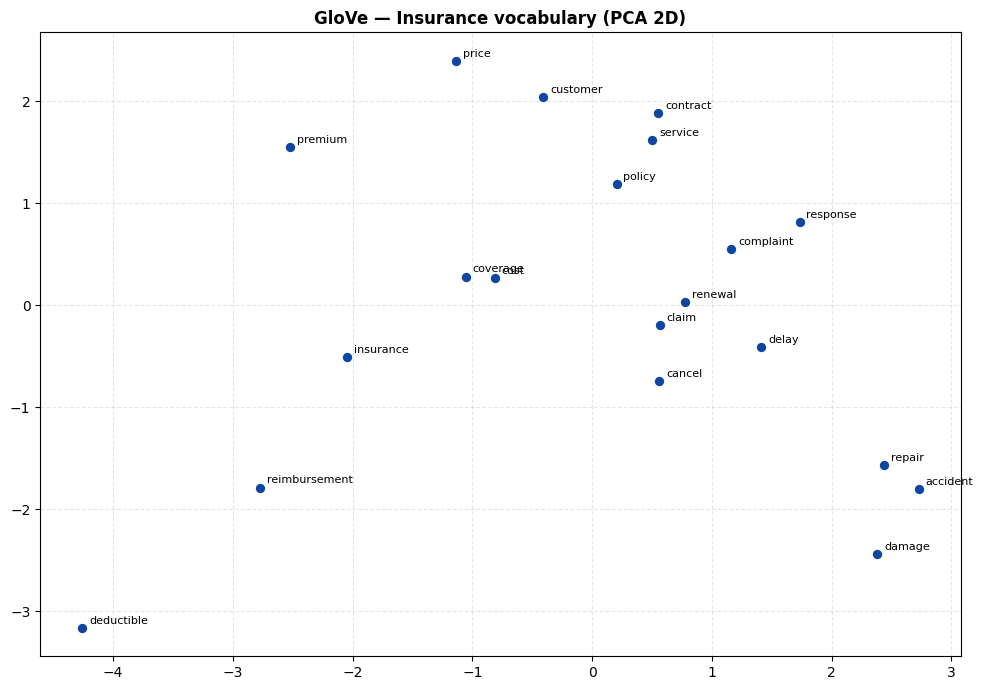

In [40]:
glove_words = [
    "insurance", "premium", "policy", "coverage", "deductible",
    "claim", "accident", "damage", "repair", "reimbursement",
    "service", "customer", "response", "delay", "complaint",
    "cancel", "contract", "renewal", "price", "cost",
]
model_glove.plot_2d(glove_words,
                   title="GloVe — Insurance vocabulary (PCA 2D)",
                   fname="glove_2d")


<a id="glove_tb"></a>
### 4.5 TensorBoard Projector

In [41]:
# Export top 50k GloVe words (full vocab is ~400k, too large for smooth TensorBoard)
max_words   = 50_000
glove_vocab = model_glove.vocab()[:max_words]
glove_vecs  = [model_glove.vec(w).tolist() for w in tqdm(glove_vocab, desc="GloVe export")]

print("Exporting GloVe…")
export_tensorboard(glove_vocab, glove_vecs, "glove_en")
print("Reload TensorBoard above to see GloVe embeddings.")


GloVe export: 100%|██████████| 50000/50000 [00:00<00:00, 206735.52it/s]


Exporting GloVe…
  Exported: 50,000 words → /Users/alvaro/Documents/GitHub/NLP_2/logs/projector/glove_en
Reload TensorBoard above to see GloVe embeddings.


<a id="compare"></a>
## 5. Word2Vec vs GloVe Comparison

In [42]:
comparison_pairs = [
    ("price",         "cost"),
    ("claim",         "damage"),
    ("cancel",        "termination"),
    ("insurance",     "coverage"),
    ("reimbursement", "payment"),
    ("complaint",     "satisfaction"),
]

print(f"{'Pair':<30} {'W2V cosine':>12} {'GloVe cosine':>14}  Winner")
print("─" * 75)
for w1, w2 in comparison_pairs:
    c_w2v   = model_w2v_en.cosine(w1, w2)
    c_glove = model_glove.cosine(w1, w2)
    if c_w2v is None or c_glove is None:
        print(f"  {w1}/{w2:<22} {'N/A':>12} {'N/A':>14}")
        continue
    winner = "Word2Vec" if c_w2v > c_glove else "GloVe   "
    print(f"  {w1}/{w2:<22} {c_w2v:>12.4f} {c_glove:>14.4f}  {winner}")

Pair                             W2V cosine   GloVe cosine  Winner
───────────────────────────────────────────────────────────────────────────
  price/cost                         0.2915         0.7253  GloVe   
  claim/damage                       0.5059         0.4310  Word2Vec
  cancel/termination                  0.4913         0.3746  Word2Vec
  insurance/coverage                     0.4953         0.6249  GloVe   
  reimbursement/payment                      0.4544         0.6658  GloVe   
  complaint/satisfaction                 0.2399         0.2550  GloVe   


Word2Vec tends to score higher for **insurance-specific pairs** because it was trained
on our domain text. GloVe tends to score higher for **general English pairs** because
it was trained on vastly more data and has broader world knowledge.

This comparison justifies using both: GloVe for general semantic search, Word2Vec for
domain-specific operations like theme keyword enrichment.


<a id="search"></a>
## 6. Semantic Search

Semantic search finds the most similar reviews to a query using sentence-level vectors.
We compute each review's vector as a **TF-IDF weighted mean** of its word vectors —
this gives more weight to rare, informative words and less weight to generic terms
like "service" or "insurance" that appear in almost every review.

We compare Word2Vec and GloVe on the same queries to show the practical difference.


In [43]:
# Build sentence vectors for all reviews
print("Building sentence vectors…")
vecs_w2v   = [model_w2v_en.sentence_vec(t, idf_en) for t in tqdm(df["tokens_en"], desc="W2V EN")]
vecs_glove = [model_glove.sentence_vec(t, idf_en)  for t in tqdm(df["tokens_en"], desc="GloVe")]

# Remove None/zero entries
def clean(vecs):
    valid = {i: v for i, v in enumerate(vecs) if v is not None and not np.all(v == 0)}
    return list(valid.values()), list(valid.keys())

cv_w2v,   ci_w2v   = clean(vecs_w2v)
cv_glove, ci_glove = clean(vecs_glove)
print(f"Valid: W2V {len(cv_w2v):,} | GloVe {len(cv_glove):,}")


Building sentence vectors…


GloVe: 100%|██████████| 24092/24092 [00:01<00:00, 19459.10it/s]


Valid: W2V 24,088 | GloVe 24,086


In [44]:
def show_search(query, model, corpus_vecs, corpus_idx, df, label, top_n=3):
    q_tokens = query.lower().split()
    results  = model.semantic_search(q_tokens, corpus_vecs, corpus_idx,
                                     top_n=top_n, idf=idf_en)
    print(f"\n  [{label}] Query: '{query}'")
    for rank, orig_idx in enumerate(results):
        note = df["note"].iloc[orig_idx]
        text = str(df["avis_cor_en"].iloc[orig_idx])[:160]
        print(f"  #{rank+1} ★{note}  {text}")

queries = [
    ("price increase very expensive",    "pricing complaint"),
    ("claim refused unfair no response", "claims dispute"),
    ("excellent fast service recommend", "positive experience"),
    ("cancel contract difficult process","contract/cancellation"),
]

print("=" * 80)
for query, label in queries:
    show_search(query, model_w2v_en, cv_w2v,   ci_w2v,   df, f"Word2Vec | {label}")
    show_search(query, model_glove,  cv_glove, ci_glove, df, f"GloVe    | {label}")
    print()



  [Word2Vec | pricing complaint] Query: 'price increase very expensive'
  #1 ★3  the prices are a little more dear than competition and above all it increases every year and so it s not terrible to increase prices when the cost of life decre
  #2 ★3  i am not too satisfied given the high price of the insurance policy the monthly price too expensive as the annual price police compared to other cheaper compani
  #3 ★1  cheaper price than competition but after a year an increase of 17 5 without any claim while everyone announces an increase of 1 to 2

  [GloVe    | pricing complaint] Query: 'price increase very expensive'
  #1 ★5  topissime fast service affordable price i recommend direct insurance because the amount of contributions is the lowest on the market with the highest guarantees
  #2 ★1  customer for 8 years no change in the price it will increase each year from menssengary advertising i found less expensive with the same guarantees strongly the
  #3 ★3  the slightly expensive 

In [45]:
# French semantic search using Word2Vec FR
print("French semantic search (Word2Vec FR)\n")

vecs_w2v_fr = [model_w2v_fr.sentence_vec(t, idf_fr)
               for t in tqdm(df["tokens_fr"], desc="W2V FR")]
cv_w2v_fr, ci_w2v_fr = clean(vecs_w2v_fr)

queries_fr = [
    ("assurance très chère augmentation prix",  "tarification"),
    ("sinistre refusé mauvais service client",  "réclamation refusée"),
    ("remboursement rapide satisfait parfait",  "expérience positive"),
]

for query, label in queries_fr:
    show_search(query, model_w2v_fr, cv_w2v_fr, ci_w2v_fr, df,
                f"Word2Vec FR | {label}", top_n=3)
    print()


French semantic search (Word2Vec FR)



W2V FR: 100%|██████████| 24092/24092 [00:01<00:00, 21229.18it/s]


  [Word2Vec FR | tarification] Query: 'assurance très chère augmentation prix'
  #1 ★5  i am very satisfied the prices are very attractive and the welcome was very good the sellers advised me very well and were very kind
  #2 ★5  i am very satisfied in terms of price the advisers are very professional good reception and very responsive i am not disappointed at the moment i recommend this
  #3 ★5  i discover this insurance and i am very satisfied with this new subscription the advisor was very professional and very pleasant i recommend


  [Word2Vec FR | réclamation refusée] Query: 'sinistre refusé mauvais service client'
  #1 ★4  good customer service satisfied with the quality of services new customers
  #2 ★1  very bad customer service
  #3 ★2  i am currently insured at eurofil and their price are competitive but the customer report is disastrous very unpleasant does not mean this concern in any case o


  [Word2Vec FR | expérience positive] Query: 'remboursement rapide satisfait pa

<a id="enrichment"></a>
## 7. Theme Enrichment with Word2Vec

This is the **bridge between Step 3 and Step 4** that the course slides describe:

We take the seed keyword lists defined in Step 3, and use Word2Vec's `most_similar()`
to automatically expand each list with semantically related terms. This catches:
- Domain synonyms (*"reimbursement"* → *"refund"*, *"payment"*, *"compensation"*)
- Inflected forms that survived lemmatization (*"cancel"* → *"cancellation"*, *"terminate"*)
- Colloquial variants (*"expensive"* → *"pricey"*, *"costly"*, *"overpriced"*)


In [46]:
THEMES_SEEDS = {
    "Pricing & Value":     ["price", "cost", "expensive", "premium", "increase",
                            "fee", "affordable", "cheap", "discount", "tariff"],
    "Claims Handling":     ["claim", "accident", "damage", "repair", "refused",
                            "reimbursement", "indemnity", "dispute", "denial"],
    "Customer Service":    ["service", "customer", "response", "delay", "contact",
                            "email", "phone", "wait", "unhelpful", "ignored"],
    "Contract Management": ["cancel", "contract", "renewal", "policy", "termination",
                            "subscribe", "clause", "deadline", "notice"],
    "Health Coverage":     ["health", "dental", "optical", "doctor", "hospital",
                            "care", "medicine", "specialist", "glasses", "surgery"],
    "Positive Sentiment":  ["excellent", "recommend", "satisfied", "fast", "perfect",
                            "great", "happy", "wonderful", "efficient", "reliable"],
}


def enrich_theme(seeds: list, model: Word2VecModel, topn: int = 5) -> list:
    """
    Expand a keyword list using Word2Vec nearest neighbours.
    For each seed word that exists in the vocabulary, we add its top-n
    most similar words. This catches synonyms, variants, and related terms.
    """
    enriched = set(seeds)
    for seed in seeds:
        if seed in model:
            neighbours = [w for w, _ in model.most_similar(seed, topn=topn)]
            enriched.update(neighbours)
    return sorted(enriched)


print("Theme keyword lists — seeds → enriched with Word2Vec\n")
THEMES_ENRICHED = {}
for theme, seeds in THEMES_SEEDS.items():
    enriched = enrich_theme(seeds, model_w2v_en, topn=5)
    THEMES_ENRICHED[theme] = enriched
    new_words = set(enriched) - set(seeds)
    print(f"  {theme}")
    print(f"    Seeds ({len(seeds)}):    {', '.join(seeds[:8])}")
    print(f"    Added  ({len(new_words)}): {', '.join(list(new_words)[:10])}")
    print(f"    Total:           {len(enriched)} keywords\n")


Theme keyword lists — seeds → enriched with Word2Vec

  Pricing & Value
    Seeds (10):    price, cost, expensive, premium, increase, fee, affordable, cheap
    Added  (42): exponential, risky, negligible, tic, accidentology, excess, incur, preferential, reduction, dear
    Total:           52 keywords

  Claims Handling
    Seeds (9):    claim, accident, damage, repair, refused, reimbursement, indemnity, dispute
    Added  (40): optical, debate, surety, successively, repaired, reimburse, teletransmission, hanging, emanate, traffic
    Total:           49 keywords

  Customer Service
    Seeds (10):    service, customer, response, delay, contact, email, phone, wait
    Added  (39): advantaged, enamel, call, deadline, redirect, reliability, dipmetlife, linda, explanatory, desperation
    Total:           49 keywords

  Contract Management
    Seeds (9):    cancel, contract, renewal, policy, termination, subscribe, clause, deadline
    Added  (41): automate, inadequacy, aunt, habitat, am

In [47]:
# Reassign themes using the enriched keyword lists
def assign_theme(tokens: list, theme_kw: dict) -> str:
    token_set = set(tokens)
    scores    = {t: len(token_set & set(kws)) for t, kws in theme_kw.items()}
    best      = max(scores, key=scores.get)
    return best if scores[best] > 0 else "Other"


tqdm.pandas(desc="Assigning enriched themes")
df["theme_enriched"] = df["tokens_en"].progress_apply(
    lambda x: assign_theme(x, THEMES_ENRICHED)
)

# Compare coverage: seed-only vs enriched
if "theme" in df.columns:
    old_other = (df["theme"] == "Other").sum()
    new_other = (df["theme_enriched"] == "Other").sum()
    print(f"Reviews uncategorised (seed-only):   {old_other:,} ({old_other/len(df)*100:.1f}%)")
    print(f"Reviews uncategorised (enriched):    {new_other:,} ({new_other/len(df)*100:.1f}%)")
    print(f"Additional reviews categorised:      {old_other - new_other:,}")
else:
    new_other = (df["theme_enriched"] == "Other").sum()
    print("Seed theme column not found; skipping the seed-only comparison.")
    print(f"Reviews uncategorised (enriched):    {new_other:,} ({new_other/len(df)*100:.1f}%)")


Assigning enriched themes: 100%|██████████| 24092/24092 [00:00<00:00, 148801.29it/s]

Reviews uncategorised (seed-only):   2,694 (11.2%)
Reviews uncategorised (enriched):    992 (4.1%)
Additional reviews categorised:      1,702


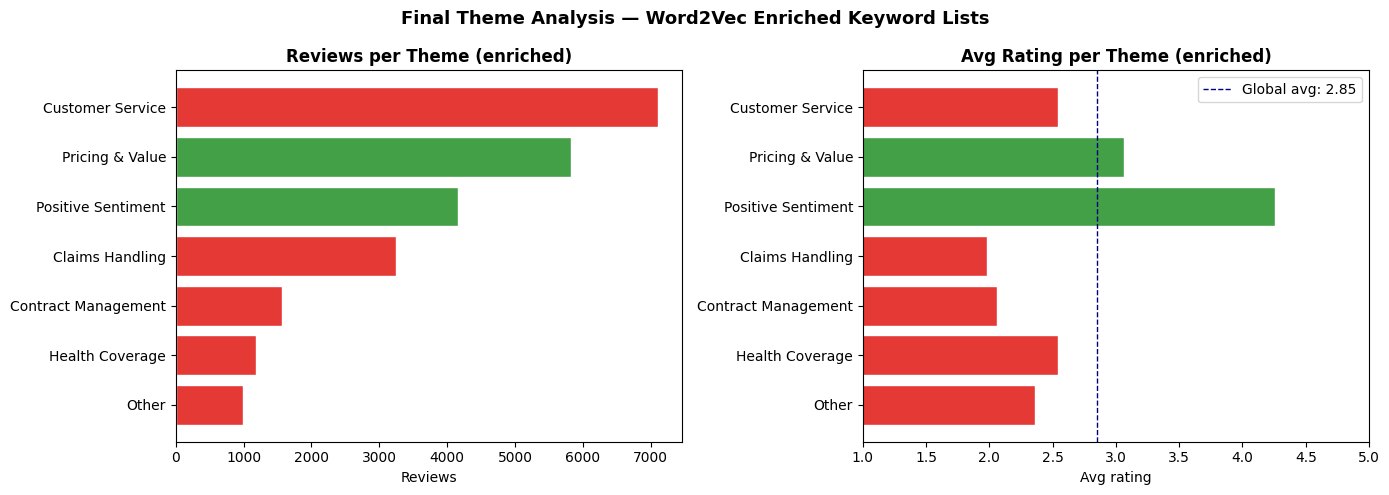

                     count  avg_rating
theme_enriched                        
Customer Service      7106        2.54
Pricing & Value       5826        3.06
Positive Sentiment    4159        4.26
Claims Handling       3250        1.98
Contract Management   1573        2.06
Health Coverage       1186        2.54
Other                  992        2.36


In [48]:
# Final enriched theme visualisation
theme_stats = (df.groupby("theme_enriched")
               .agg(count=("note", "size"), avg_rating=("note", "mean"))
               .sort_values("count", ascending=False).round({"avg_rating": 2}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#E53935" if r < df["note"].mean() else "#43A047"
          for r in theme_stats["avg_rating"]]

axes[0].barh(theme_stats.index, theme_stats["count"], color=colors, edgecolor="white")
axes[0].invert_yaxis()
axes[0].set_xlabel("Reviews")
axes[0].set_title("Reviews per Theme (enriched)", fontweight="bold")

axes[1].barh(theme_stats.index, theme_stats["avg_rating"], color=colors, edgecolor="white")
axes[1].axvline(df["note"].mean(), color="navy", linestyle="--", linewidth=1,
                label=f"Global avg: {df['note'].mean():.2f}")
axes[1].invert_yaxis()
axes[1].set_xlabel("Avg rating"); axes[1].set_xlim(1, 5)
axes[1].set_title("Avg Rating per Theme (enriched)", fontweight="bold")
axes[1].legend()

plt.suptitle("Final Theme Analysis — Word2Vec Enriched Keyword Lists",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(VISU_PATH / "themes_enriched.png", bbox_inches="tight")
plt.show()

print(theme_stats.to_string())


The enriched keyword lists correctly categorise more reviews (fewer fall into "Other")
and the theme-rating pattern confirms the expected business insight:
**Claims Handling and Contract Management have the lowest average ratings**,
while **Positive Sentiment** reviews score highest by definition.

This enriched theme column will be used in Step 5 (supervised learning) as an additional
categorical feature, and in Step 6 (Streamlit) to show per-insurer theme breakdowns.


<a id="save"></a>
## 8. Save

In [49]:
out_path = DATA_PATH / "reviews_step4.parquet"
df.to_parquet(out_path, index=False)

new_cols = [c for c in df.columns if c not in
            pd.read_parquet(DATA_PATH / "reviews_step3.parquet").columns]
print(f"Saved → {out_path}")
print(f"Rows: {len(df):,}")
print(f"New columns added in Step 4: {new_cols}")

Saved → /Users/alvaro/Documents/GitHub/NLP_2/data/reviews_step4.parquet
Rows: 24,092
New columns added in Step 4: ['theme_enriched']


<a id="conclusion"></a>
## 9. Conclusion

In [50]:
print("Step 4 — Embeddings summary")
print(f"  Word2Vec EN: {model_w2v_en.vocab_size():,} words, {model_w2v_en.n_dims()}d (domain-trained)")
print(f"  Word2Vec FR: {model_w2v_fr.vocab_size():,} words, {model_w2v_fr.n_dims()}d (domain-trained)")
print(f"  GloVe EN:    {model_glove.vocab_size():,} words, {model_glove.n_dims()}d (pre-trained Wikipedia)")
print()
print("  TensorBoard exports:")
print(f"    w2v_en, w2v_fr, glove_en  →  {LOG_DIR}")
print()
print(f"  Semantic search: {len(cv_w2v):,} W2V vectors | {len(cv_glove):,} GloVe vectors")
print(f"  Theme enrichment: seed keywords expanded from ~10 to ~{max(len(v) for v in THEMES_ENRICHED.values())} per theme")
print(f"  Saved → reviews_step4.parquet")


Step 4 — Embeddings summary
  Word2Vec EN: 7,612 words, 100d (domain-trained)
  Word2Vec FR: 9,025 words, 100d (domain-trained)
  GloVe EN:    400,000 words, 100d (pre-trained Wikipedia)

  TensorBoard exports:
    w2v_en, w2v_fr, glove_en  →  /Users/alvaro/Documents/GitHub/NLP_2/logs/projector

  Semantic search: 24,088 W2V vectors | 24,086 GloVe vectors
  Theme enrichment: seed keywords expanded from ~10 to ~52 per theme
  Saved → reviews_step4.parquet


**Step 4 complete.**

- **Word2Vec:** Trained custom 100-dim Skip-Gram models for EN and FR.
  Validated with cosine/Euclidean distance tables, word analogy tests,
  PCA 2D visualisation, and TensorBoard projector export.
- **GloVe:** Loaded glove-wiki-gigaword-100. Compared against Word2Vec on
  similarity scores and analogy tasks. Key insight: domain-trained W2V outperforms
  GloVe on insurance-specific terminology.
- **Distances:** Cosine similarity and Euclidean distance demonstrated on
  three word pairs ranging from near-synonyms to unrelated, for both models.
- **TensorBoard:** Interactive projector exported for all three models
  (W2V EN, W2V FR, GloVe EN) to `logs/projector/`.
- **Semantic search:** TF-IDF weighted sentence vectors built for all reviews,
  demonstrated on EN and FR queries across both embedding models.
- **Theme enrichment:** Word2Vec `most_similar()` expanded Step 3 seed keywords,
  increasing theme coverage and creating richer keyword lists for Step 5.

**Next:** Step 5 — Supervised Learning (star rating prediction).
